# Modeling

In [1]:
!pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

## Data Preview

In [3]:
df = pd.read_csv('../datasets/normalized_data/combined_normalized.csv')
df

,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Dist to CBD in Km,Sale Months Since Sep 2025,Num MRT Within 1km,Num Hawker Within 1km,Num Malls Within 1km,Num Hospitals Within 5km,Num Schools Within 2km,Num Parks Within 1km,Floor_Level_Category,Type_of_Sale_Encoded,Property_Type_Encoded,Market_Segment_Encoded,District
0,-0.211237,-0.460443,0.774350,1.347673,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,-1.619747,-1.228179,-0.334688,1.124971,1
1,-0.087630,-0.460443,1.240198,1.347673,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,0.947931,-1.228179,-0.334688,1.124971,1
2,-0.303362,-0.331436,-0.058154,-0.618836,-1.117103,-0.723616,-0.407922,0.640686,0.276567,-0.286674,0.161507,-0.152502,0.814214,2.987854,-0.888912,1
3,-0.100129,-0.442004,1.103809,1.347673,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,0.214309,-1.228179,-0.334688,1.124971,1
4,1.493910,2.267081,-0.950882,-0.363508,-1.117103,0.183604,-0.407922,0.156402,-0.670176,-0.286674,-0.030473,-1.619747,0.814214,-0.334688,-0.888912,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104128,-0.947937,-0.579614,-0.985079,0.574579,1.673034,0.833925,1.313703,-0.328072,-0.506403,0.980484,-0.613859,1.310748,0.037050,-1.351717,0.000000,28
104129,-0.937078,0.166615,-2.397949,-1.124401,1.673034,-1.632820,-1.555130,-1.985871,2.556176,-1.696390,1.710013,-0.905237,0.037050,0.739800,0.000000,28
104130,-1.023949,-0.888409,-0.204967,0.512166,1.673034,0.340576,-0.120714,-0.328072,-0.506403,-0.506668,-0.355651,2.049409,0.037050,-1.351717,0.000000,28
104131,0.702603,1.504712,-1.513821,0.246256,1.673034,0.833925,1.313703,1.329727,-0.506403,0.980484,-0.872068,-0.905237,0.037050,0.739800,0.000000,28


## Simple Linear Regression

In [7]:
print("Simple Linear Regression Modeling for Singapore Private Residential Property Prices")

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# CONFIG
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
# keep only existing columns
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 30   
EPS = 1e-6       

def safe_mape(y_true, y_pred):
    # clip true values to avoid division by zero
    return mean_absolute_percentage_error(np.maximum(y_true, EPS), y_pred)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'r2_full': r2_score(y_true, y_pred),
        'rmse_full': mean_squared_error(y_true, y_pred, squared=False),
        'mae_full': mean_absolute_error(y_true, y_pred),
        'mape_full': safe_mape(y_true, y_pred)
    }

rows = []
for feature in feature_cols:
    sub = df[[feature, target_col]].dropna().copy()
    n = len(sub)
    if n < MIN_ROWS:
        print(f"Skipping '{feature}' — only {n} rows (< {MIN_ROWS})")
        continue

    # Ensure numeric values
    try:
        X_full = sub[feature].astype(float).values.reshape(-1, 1)
        y_full = sub[target_col].astype(float).values
    except Exception as e:
        print(f"Skipping '{feature}' — conversion to float failed: {e}")
        continue

    # Fit on full data
    lr = LinearRegression()
    lr.fit(X_full, y_full)
    y_full_pred = lr.predict(X_full)
    full_metrics = compute_metrics(y_full, y_full_pred)

    # Cross-validated metrics
    n_splits = min(CV_FOLDS, n) if n >= 2 else 2

    # If too few samples for requested folds, reduce folds
    if n_splits < 2:
        print(f"Skipping CV for '{feature}' — insufficient samples: n={n}")
        continue

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_r2_list = []
    cv_rmse_list = []
    cv_mae_list = []
    cv_mape_list = []
    folds_used = 0

    for train_idx, val_idx in kf.split(X_full):
        X_tr, X_val = X_full[train_idx], X_full[val_idx]
        y_tr, y_val = y_full[train_idx], y_full[val_idx]

        if np.unique(y_tr).size < 2:
            continue

        model = LinearRegression()
        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        cv_r2_list.append(r2_score(y_val, y_val_pred))
        cv_rmse_list.append(mean_squared_error(y_val, y_val_pred, squared=False))
        cv_mae_list.append(mean_absolute_error(y_val, y_val_pred))
        cv_mape_list.append(safe_mape(y_val, y_val_pred))
        folds_used += 1

    if folds_used == 0:
        print(f"No valid CV folds for '{feature}' (n={n}). Skipping feature.")
        continue

    row = {
        'feature': feature,
        'n': n,
        # full-sample
        'r2_full': full_metrics['r2_full'],
        'rmse_full': full_metrics['rmse_full'],
        'mae_full': full_metrics['mae_full'],
        'mape_full': full_metrics['mape_full'],
        # CV averages
        'cv_r2_mean': np.mean(cv_r2_list),
        'cv_r2_std': np.std(cv_r2_list),
        'cv_rmse_mean': np.mean(cv_rmse_list),
        'cv_mae_mean': np.mean(cv_mae_list),
        'cv_mape_mean': np.mean(cv_mape_list),
        'cv_folds_used': folds_used
    }
    rows.append(row)

results_df = pd.DataFrame(rows)
if results_df.empty:
    print("No features produced valid results. Check data and MIN_ROWS.")
else:
    # Sort by cv_r2_mean descending
    results_df = results_df.sort_values('cv_r2_mean', ascending=False).reset_index(drop=True)

    # Print results 
    pd.set_option('display.float_format', lambda x: f"{x:0.4f}")
    print("\n=== Single-feature linear regression results (sorted by CV R² mean) ===\n")
    display_cols = ['feature','n','r2_full','cv_r2_mean','cv_r2_std','cv_rmse_mean','cv_mae_mean','cv_mape_mean']
    print(results_df[display_cols].to_string(index=False))

    # Best feature
    best = results_df.iloc[0]
    print("\n" + "="*60)
    print(f"Best feature: {best['feature']}")
    print(f"Samples: {int(best['n'])}")
    print(f"Full R² = {best['r2_full']:.4f}")
    print(f"CV R² mean = {best['cv_r2_mean']:.4f} (std {best['cv_r2_std']:.4f})")
    print(f"CV RMSE = {best['cv_rmse_mean']:.2f}, CV MAE = {best['cv_mae_mean']:.2f}, CV MAPE = {best['cv_mape_mean']:.4f}")
    print("="*60)


Simple Linear Regression Modeling for Singapore Private Residential Property Prices

=== Single-feature linear regression results (sorted by CV R² mean) ===

                   feature      n  r2_full  cv_r2_mean  cv_r2_std  cv_rmse_mean  cv_mae_mean  cv_mape_mean
Sale Months Since Sep 2025 104133   0.0416      0.0425     0.0072        0.9809       0.6406   106656.3037
      Type_of_Sale_Encoded 104133   0.0329      0.0337     0.0057        0.9853       0.6467    94454.5586
      Floor_Level_Category 104133   0.0129      0.0133     0.0035        0.9956       0.6527    53849.1689
    Market_Segment_Encoded 104133   0.0051      0.0052     0.0006        0.9996       0.6548    22307.4083
  Num Hospitals Within 5km 104133   0.0027      0.0028     0.0010        1.0008       0.6554    23060.2893
         Dist to CBD in Km 104133   0.0022      0.0023     0.0006        1.0011       0.6554    22873.1208
     Num Hawker Within 1km 104133   0.0004      0.0003     0.0003        1.0020       0.6567 

## Simple Linear Regression Per District

In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("="*80)
print("SIMPLE LINEAR REGRESSION ANALYSIS - PER DISTRICT")
print("="*80)

target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# Ensure required columns exist 
for col in [target_col, 'District']:
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")

districts = sorted(df['District'].dropna().unique().astype(int))

district_results = []

# 1. Loop over districts 
for dist in districts:
    df_dist = df[df['District'] == dist].copy()
    if len(df_dist) < 50:  # skip small districts
        continue

    print(f"\n=== District {dist} (n={len(df_dist)}) ===")

    results = []
    for feature in feature_cols:
        subset = df_dist[[feature, target_col]].dropna()
        if subset.empty:
            continue
        X = subset[[feature]]
        y = subset[target_col]

        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        coef = model.coef_[0]
        r2 = r2_score(y, y_pred)

        results.append((feature, coef, r2))

    if not results:
        continue

    # Sort by R²
    results_df = (
        pd.DataFrame(results, columns=['Feature', 'Coefficient', 'R²'])
        .sort_values('R²', ascending=False)
        .reset_index(drop=True)
    )

    # Append to master list
    for _, row in results_df.iterrows():
        district_results.append({
            'District': dist,
            'Feature': row['Feature'],
            'Coefficient': row['Coefficient'],
            'R²': row['R²']
        })

    # Display top features for this district
    print("Top features by R²:\n", results_df.head(5), "\n")

# 2. Combine all district results
all_results_df = pd.DataFrame(district_results)

# Sort by district and then by R² descending
all_results_df = all_results_df.sort_values(['District', 'R²'], ascending=[True, False]).reset_index(drop=True)

# 3. Display summary
print("\n===== Summary of Feature Impact by District (Sorted by R²) =====\n")
print(all_results_df.head(30)) 


SIMPLE LINEAR REGRESSION ANALYSIS - PER DISTRICT

=== District 1 (n=1638) ===
Top features by R²:
                       Feature  Coefficient     R²
0       Property_Type_Encoded       0.2226 0.0495
1        Floor_Level_Category       0.1919 0.0368
2      Market_Segment_Encoded      -0.1141 0.0130
3  Sale Months Since Sep 2025       0.0830 0.0069
4           Dist to CBD in Km      -0.0787 0.0062 


=== District 2 (n=1207) ===
Top features by R²:
                  Feature  Coefficient     R²
0   Floor_Level_Category       0.3048 0.0918
1   Num Malls Within 1km       0.2991 0.0881
2   Num Parks Within 1km       0.2783 0.0776
3  Num Hawker Within 1km       0.2560 0.0653
4     Num MRT Within 1km       0.2494 0.0611 


=== District 3 (n=4625) ===
Top features by R²:
                       Feature  Coefficient     R²
0        Num Parks Within 1km       0.3331 0.1082
1        Type_of_Sale_Encoded      -0.2604 0.0660
2           Dist to CBD in Km       0.2437 0.0594
3    Num Hospitals Within 5

## Multiple Linear Regression

In [9]:
print("Multiple Linear Regression Modeling for Singapore Private Residential Property Prices")

import itertools
import math
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

df_work = df.copy()                       
target_col = 'Transacted Price ($)'       

candidate_features = [
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'District'
]

candidate_features = [c for c in candidate_features if c in df_work.columns]

MIN_ROWS_PER_MODEL = lambda k: max(40, 5 * k)   
CV_FOLDS = 5
RANDOM_STATE = 42
USE_TQDM = True

# Limit number combos per k for very large feature sets (if needed)
max_combinations_per_k = None  

# Compute metrics 
def compute_metrics(y_true, y_pred):
    # ensure numpy arrays
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # handle MAPE edge cases: sklearn's MAPE will error if y_true contains zeros badly scaled; add small eps
    eps = 1e-6
    mape = mean_absolute_percentage_error(np.maximum(y_true, eps), y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}

all_summary = []   # store all combos summary for later ranking
best_per_k = {}    # store best combo for each k

# iterate k = 2 to number of available features
max_k = min(12, len(candidate_features))
for k in range(2, max_k + 1):
    combos = list(itertools.combinations(candidate_features, k))
    if max_combinations_per_k is not None and len(combos) > max_combinations_per_k:
        combos = combos[:max_combinations_per_k] 
    comb_iter = tqdm(combos, desc=f"k={k}", ncols=80) if USE_TQDM else combos

    best_combo_for_k = None
    best_cv_r2 = -np.inf

    for combo in comb_iter:
        combo = list(combo)
        sub = df_work[combo + [target_col]].dropna()
        n = len(sub)
        if n < MIN_ROWS_PER_MODEL(k):
            # insufficient samples for this combo; skip
            continue

        X_full = sub[combo].astype(float).values
        y_full = sub[target_col].astype(float).values

        # Fit on full sample (for full-sample R2)
        lr = LinearRegression()
        try:
            lr.fit(X_full, y_full)
        except Exception:
            continue
        y_full_pred = lr.predict(X_full)
        metrics_full = compute_metrics(y_full, y_full_pred)

        # Cross-validation metrics
        kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_r2s = []
        cv_rmses = []
        cv_maes = []
        cv_mapes = []
        fold_count = 0
        for tr_idx, val_idx in kf.split(X_full, y_full):
            X_tr, X_val = X_full[tr_idx], X_full[val_idx]
            y_tr, y_val = y_full[tr_idx], y_full[val_idx]

            if np.unique(y_tr).shape[0] < 2:
                continue
            model_cv = LinearRegression()
            try:
                model_cv.fit(X_tr, y_tr)
                y_val_pred = model_cv.predict(X_val)
            except Exception:
                continue
            m = compute_metrics(y_val, y_val_pred)
            cv_r2s.append(m['r2'])
            cv_rmses.append(m['rmse'])
            cv_maes.append(m['mae'])
            cv_mapes.append(m['mape'])
            fold_count += 1

        if fold_count == 0:
            continue

        cv_r2_mean = np.mean(cv_r2s)
        cv_r2_std = np.std(cv_r2s)
        cv_rmse_mean = np.mean(cv_rmses)
        cv_mae_mean = np.mean(cv_maes)
        cv_mape_mean = np.mean(cv_mapes)

        record = {
            'k': k,
            'features': combo,
            'n': n,
            # full-sample metrics (on training)
            'r2_full': metrics_full['r2'],
            'rmse_full': metrics_full['rmse'],
            'mae_full': metrics_full['mae'],
            'mape_full': metrics_full['mape'],
            # CV metrics (mean across folds)
            'cv_r2_mean': cv_r2_mean,
            'cv_r2_std': cv_r2_std,
            'cv_rmse_mean': cv_rmse_mean,
            'cv_mae_mean': cv_mae_mean,
            'cv_mape_mean': cv_mape_mean,
            'folds_used': fold_count
        }
        all_summary.append(record)

        # track best by cv_r2_mean for this k
        if cv_r2_mean > best_cv_r2:
            best_cv_r2 = cv_r2_mean
            best_combo_for_k = record

    # Store best for this k
    if best_combo_for_k is not None:
        best_per_k[k] = best_combo_for_k
        # print best combo for this k (formatted)
        print("\n" + "="*70)
        print(f"Best combo for k={k}  (CV R² mean = {best_combo_for_k['cv_r2_mean']:.4f})")
        print("Features:", best_combo_for_k['features'])
        print(f"n = {best_combo_for_k['n']}, folds used = {best_combo_for_k['folds_used']}")
        print(f"Full R² = {best_combo_for_k['r2_full']:.4f}")
        print(f"CV RMSE = {best_combo_for_k['cv_rmse_mean']:.2f}, CV MAE = {best_combo_for_k['cv_mae_mean']:.2f}, CV MAPE = {best_combo_for_k['cv_mape_mean']:.4f}")
        print("="*70)
    else:
        print(f"\nNo valid combos found for k={k} (insufficient data or numeric issues).")

# Final summary: choose overall best combo across all k by cv_r2_mean 
if len(all_summary) == 0:
    print("\nNo models were fitted (check MIN_ROWS_PER_MODEL or data completeness).")
else:
    all_df = pd.DataFrame(all_summary)
    all_df_sorted = all_df.sort_values('cv_r2_mean', ascending=False).reset_index(drop=True)
    overall_best = all_df_sorted.iloc[0]
    print("\n" + "#" * 80)
    print("OVERALL BEST COMBINATION (ranked by CV R² mean):")
    print(f"k = {overall_best['k']}, features = {overall_best['features']}")
    print(f"n = {overall_best['n']}, folds used = {overall_best['folds_used']}")
    print(f"Full R² = {overall_best['r2_full']:.4f}")
    print(f"CV R² mean = {overall_best['cv_r2_mean']:.4f} (std {overall_best['cv_r2_std']:.4f})")
    print(f"CV RMSE = {overall_best['cv_rmse_mean']:.2f}, CV MAE = {overall_best['cv_mae_mean']:.2f}, CV MAPE = {overall_best['cv_mape_mean']:.4f}")
    print("#" * 80)


Multiple Linear Regression Modeling for Singapore Private Residential Property Prices


k=2: 100%|██████████████████████████████████████| 78/78 [00:04<00:00, 16.32it/s]



Best combo for k=2  (CV R² mean = 0.0792)
Features: ['Sale Months Since Sep 2025', 'Type_of_Sale_Encoded']
n = 104133, folds used = 5
Full R² = 0.0772
CV RMSE = 0.96, CV MAE = 0.63, CV MAPE = 127808.6420


k=3: 100%|████████████████████████████████████| 286/286 [00:35<00:00,  8.01it/s]



Best combo for k=3  (CV R² mean = 0.0862)
Features: ['Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded']
n = 104133, folds used = 5
Full R² = 0.0840
CV RMSE = 0.96, CV MAE = 0.63, CV MAPE = 133563.4228


...


Best combo for k=10  (CV R² mean = 0.0967)
Features: ['Num MRT Within 1km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 104133, folds used = 5
Full R² = 0.0946
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 143250.5175


k=11: 100%|█████████████████████████████████████| 78/78 [00:13<00:00,  5.70it/s]



Best combo for k=11  (CV R² mean = 0.0967)
Features: ['Num MRT Within 1km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 104133, folds used = 5
Full R² = 0.0946
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 143115.1681


k=12: 100%|█████████████████████████████████████| 13/13 [00:02<00:00,  5.24it/s]


Best combo for k=12  (CV R² mean = 0.0967)
Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 104133, folds used = 5
Full R² = 0.0946
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 143112.1231

################################################################################
OVERALL BEST COMBINATION (ranked by CV R² mean):
k = 11, features = ['Num MRT Within 1km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 104133, folds used = 5
Full R² = 0.0946
CV R² mean = 0.0967 (std 0.0152)
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 143115.

## Ridge Regression

In [4]:
print("Ridge Regression Modeling for Singapore Private Residential Property Prices")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("DATA PREPARATION")

df = pd.read_csv('../datasets/normalized_data/combined_normalized.csv')

print(f"Loaded {len(df)} property transactions")
print(f"   Date range: {df['Sale Months Since Sep 2025'].min():.2f} to {df['Sale Months Since Sep 2025'].max():.2f} months")
print(f"   Districts: {df['District'].nunique()}")
print(f"   Features: {len(df.columns)}")

# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"\nWARNING: Found {missing.sum()} missing values")
    print(missing[missing > 0])
    df = df.dropna()
    print(f"   After dropping: {len(df)} transactions remain")
else:
    print(f"\nNo missing values found")


print("\nFEATURE ENGINEERING")

location_features = ['Dist to CBD in Km']
amenity_features = [
    'Num MRT Within 1km', 
    'Num Hawker Within 1km', 
    'Num Malls Within 1km', 
    'Num Hospitals Within 5km', 
    'Num Schools Within 2km', 
    'Num Parks Within 1km'
]
property_features = [
    'Area (SQFT)',
    'Floor_Level_Category', 
    'Type_of_Sale_Encoded', 
    'Property_Type_Encoded', 
    'Market_Segment_Encoded'
]
time_features = ['Sale Months Since Sep 2025']

base_features = location_features + amenity_features + property_features + time_features

print(f"\nFeature Summary:")
print(f"   Location features: {len(location_features)}")
print(f"   Amenity features: {len(amenity_features)}")
print(f"   Property features: {len(property_features)}")
print(f"   Time features: {len(time_features)}")

district_dummies = pd.get_dummies(df['District'], prefix='District', drop_first=True)

print(f"District dummies: {len(district_dummies.columns)} (baseline: District {df['District'].min()})")

X_base = df[base_features].copy()
X = pd.concat([X_base, district_dummies], axis=1)
y = df['Transacted Price ($)'].copy()

print(f"   TOTAL FEATURES: {X.shape[1]}")
print(f"   TOTAL SAMPLES: {len(X)}")

print("\n MULTICOLLINEARITY CHECK (VIF)")

# Calculate VIF 
vif_data = pd.DataFrame()
vif_data["Feature"] = base_features

vif_values = []
for i in range(len(base_features)):
    try:
        vif = variance_inflation_factor(X[base_features].values, i)
        vif_values.append(vif)
    except:
        vif_values.append(np.nan)

vif_data["VIF"] = vif_values
vif_data = vif_data.sort_values('VIF', ascending=False)

print(f"\nVariance Inflation Factor (VIF) Analysis:")
print(f"   VIF < 5:  Low multicollinearity")
print(f"   VIF 5-10: Moderate multicollinearity")
print(f"   VIF > 10: High multicollinearity")
print("\n" + "-"*60)
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n{len(high_vif)} features have high multicollinearity")
    print(high_vif[['Feature', 'VIF']].to_string(index=False))
    print(f"\n   Ridge regression will help stabilize coefficients!")
else:
    print(f"\nAll features have acceptable VIF values")

print("\nFINDING OPTIMAL RIDGE REGULARIZATION (ALPHA) --> Hyperparameter Tuning")

alphas = np.logspace(-3, 3, 100)  # From 0.001 to 1000

ridge_cv = RidgeCV(alphas=alphas, cv=10, scoring='r2')
ridge_cv.fit(X, y)

optimal_alpha = ridge_cv.alpha_
print(f"\nOptimal Alpha: {optimal_alpha:.6f}")
print(f"   10-Fold CV R²: {ridge_cv.best_score_:.4f}")
print(f"\nUsing ALL {len(X)} samples for analysis (no train/test split)")
print(f"   Cross-validation ensures robust parameter selection")

print("\nFINAL RIDGE REGRESSION MODEL")

# Use optimal alpha from cross-validation
model = Ridge(alpha=optimal_alpha)
model.fit(X, y)

print(f"\n✅ Ridge Regression Model:")
print(f"   Alpha: {optimal_alpha:.6f}")
print(f"   Features: {len(model.coef_)} (all retained)")
print(f"   Samples: {len(X)}")

print("\nMODEL PERFORMANCE METRICS")

# Predictions on all data
y_pred = model.predict(X)

# Calculate metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

def mape(y_true, y_pred):
    y_true_actual = y_true * df['Transacted Price ($)'].std() + df['Transacted Price ($)'].mean()
    y_pred_actual = y_pred * df['Transacted Price ($)'].std() + df['Transacted Price ($)'].mean()
    
    mask = y_true_actual != 0
    return np.mean(np.abs((y_true_actual[mask] - y_pred_actual[mask]) / y_true_actual[mask])) * 100


print(f"\nMODEL FIT METRICS (All Data):")
print(f"   R² Score:  {r2:.4f}  ({r2*100:.2f}% of variance explained)")
print(f"   RMSE:      {rmse:.4f} (normalized)")
print(f"   MAE:       {mae:.4f} (normalized)")

print(f"\n10-Fold Cross-Validation (Robustness Check):")
cv_r2_scores = cross_val_score(model, X, y, cv=10, scoring='r2')
cv_mae_scores = -cross_val_score(model, X, y, cv=10, scoring='neg_mean_absolute_error')

print(f"   R² Score:")
print(f"      Mean: {cv_r2_scores.mean():.4f}")
print(f"      Std:  {cv_r2_scores.std():.4f}")
print(f"      Range: [{cv_r2_scores.min():.4f}, {cv_r2_scores.max():.4f}]")

print(f"\n   MAE:")
print(f"      Mean: {cv_mae_scores.mean():.4f}")
print(f"      Std:  {cv_mae_scores.std():.4f}")

# Interpret the gap
cv_gap = r2 - cv_r2_scores.mean()
print(f"\nMODEL STABILITY:")
print(f"   R² Gap (Full Model - CV Mean): {cv_gap:.4f}")
if cv_gap > 0.05:
    print(f"   Moderate optimism - model fits training data better than CV suggests")
elif cv_gap > 0.02:
    print(f"   Good - small optimism is normal")
else:
    print(f"   Excellent - very stable model!")

print(f"\nInterpretation:")
print(f"   • R² = {r2:.4f} means the model explains {r2*100:.1f}% of price variation")
print(f"   • Cross-validation R² = {cv_r2_scores.mean():.4f} suggests similar performance")
print(f"     on unseen data folds")

# Residual analysis
residuals = y - y_pred
print(f"\nRESIDUAL ANALYSIS:")
print(f"   Mean residual: {residuals.mean():.6f} (should be ~0)")
print(f"   Std residual:  {residuals.std():.4f}")
print(f"   Min residual:  {residuals.min():.4f}")
print(f"   Max residual:  {residuals.max():.4f}")

Ridge Regression Modeling for Singapore Private Residential Property Prices
DATA PREPARATION
Loaded 104133 property transactions
   Date range: -4.39 to 2.88 months
   Districts: 27
   Features: 16

No missing values found

FEATURE ENGINEERING

Feature Summary:
   Location features: 1
   Amenity features: 6
   Property features: 5
   Time features: 1
District dummies: 26 (baseline: District 1)
   TOTAL FEATURES: 39
   TOTAL SAMPLES: 104133

 MULTICOLLINEARITY CHECK (VIF)

Variance Inflation Factor (VIF) Analysis:
   VIF < 5:  Low multicollinearity
   VIF 5-10: Moderate multicollinearity
   VIF > 10: High multicollinearity

------------------------------------------------------------
                   Feature      VIF
         Dist to CBD in Km 1.743033
  Num Hospitals Within 5km 1.526258
    Market_Segment_Encoded 1.262860
      Num Malls Within 1km 1.251256
        Num MRT Within 1km 1.219675
    Num Schools Within 2km 1.203934
      Type_of_Sale_Encoded 1.185563
     Num Hawker With

In [5]:
print("\nCOEFFICIENT ANALYSIS")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

district_coefs = coef_df[coef_df['Feature'].str.startswith('District_')].copy()
other_coefs = coef_df[~coef_df['Feature'].str.startswith('District_')].copy()


print("\nBASE FEATURE COEFFICIENTS (Non-District)")
print(other_coefs.to_string(index=False))

print("\nINTERPRETATION:")
print("   • Positive coefficient → Increases property price")
print("   • Negative coefficient → Decreases property price")
print("   • Magnitude indicates strength of relationship")
print("   • All features are normalized (mean=0, std=1) for fair comparison")

print("\nTOP POSITIVE EFFECTS:")
top_positive = other_coefs.nlargest(3, 'Coefficient')
for idx, row in top_positive.iterrows():
    print(f"   • {row['Feature']}: {row['Coefficient']:.4f}")
    
print("\nTOP NEGATIVE EFFECTS:")
top_negative = other_coefs.nsmallest(3, 'Coefficient')
for idx, row in top_negative.iterrows():
    print(f"   • {row['Feature']}: {row['Coefficient']:.4f}")


print("\nDISTRICT COEFFICIENTS (vs. Baseline District)")
print("-"*80)

baseline_district = df['District'].min()
print(f"\nBaseline District: District {baseline_district}")
print(f"   All other districts are compared to this baseline\n")

print(district_coefs.to_string(index=False))

print("\nINTERPRETATION:")
print(f"   • Positive coefficient → More expensive than District {baseline_district}")
print(f"   • Negative coefficient → Less expensive than District {baseline_district}")
print("   • Coefficient shows the price premium/discount")

# Highlight premium 
print("\nPREMIUM DISTRICTS (Highest Price Premium):")
premium_districts = district_coefs.nlargest(5, 'Coefficient')
for idx, row in premium_districts.iterrows():
    district_num = row['Feature'].replace('District_', '')
    print(f"   • District {district_num}: +{row['Coefficient']:.4f} (vs. baseline)")

print("\nBUDGET DISTRICTS (Largest Price Discount):")
budget_districts = district_coefs.nsmallest(5, 'Coefficient')
for idx, row in budget_districts.iterrows():
    district_num = row['Feature'].replace('District_', '')
    print(f"   • District {district_num}: {row['Coefficient']:.4f} (vs. baseline)")


print("\nGENERATING COEFFICIENT VISUALIZATIONS")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

other_coefs_sorted = other_coefs.sort_values('Coefficient')
colors = ['red' if x < 0 else 'green' for x in other_coefs_sorted['Coefficient']]

ax1.barh(range(len(other_coefs_sorted)), other_coefs_sorted['Coefficient'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(other_coefs_sorted)))
ax1.set_yticklabels(other_coefs_sorted['Feature'], fontsize=9)
ax1.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax1.set_title('Base Feature Coefficients\n(Green = Positive Effect, Red = Negative Effect)', 
              fontsize=13, fontweight='bold')
ax1.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax1.grid(axis='x', alpha=0.3)

district_coefs_sorted = district_coefs.sort_values('Coefficient')
colors_district = ['red' if x < 0 else 'green' for x in district_coefs_sorted['Coefficient']]
district_labels = [f"D{x.replace('District_', '')}" for x in district_coefs_sorted['Feature']]

ax2.barh(range(len(district_coefs_sorted)), district_coefs_sorted['Coefficient'], 
         color=colors_district, alpha=0.7)
ax2.set_yticks(range(len(district_coefs_sorted)))
ax2.set_yticklabels(district_labels, fontsize=8)
ax2.set_xlabel('Coefficient Value (vs. Baseline)', fontsize=12, fontweight='bold')
ax2.set_title(f'District Price Effects (vs. District {baseline_district})\n(Green = Premium, Red = Discount)', 
              fontsize=13, fontweight='bold')
ax2.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/ridge/coefficient_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved: ./outputs/ridge/coefficient_analysis.png")

# Feature Importance by Category
print("\nGenerating feature importance by category...")

feature_categories = {
    'Location': location_features,
    'Amenities': amenity_features,
    'Property': property_features,
    'Time': time_features
}

category_importance = {}
for category, features in feature_categories.items():
    coefs_in_category = other_coefs[other_coefs['Feature'].isin(features)]['Coefficient'].abs().sum()
    category_importance[category] = coefs_in_category

category_df = pd.DataFrame(list(category_importance.items()), 
                          columns=['Category', 'Total Absolute Coefficient'])
category_df = category_df.sort_values('Total Absolute Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(category_df['Category'], category_df['Total Absolute Coefficient'], 
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax.set_ylabel('Total Absolute Coefficient', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Category', fontsize=12, fontweight='bold')
ax.set_title('Feature Category Importance\n(Sum of Absolute Coefficients)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./outputs/ridge/category_importance.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved: ./outputs/ridge/category_importance.png")

print("\n" + category_df.to_string(index=False))

print("\nCOEFFICIENT SUMMARY")

summary_stats = pd.DataFrame({
    'Category': ['Base Features', 'District Effects', 'All Features'],
    'Count': [len(other_coefs), len(district_coefs), len(coef_df)],
    'Positive': [
        (other_coefs['Coefficient'] > 0).sum(),
        (district_coefs['Coefficient'] > 0).sum(),
        (coef_df['Coefficient'] > 0).sum()
    ],
    'Negative': [
        (other_coefs['Coefficient'] < 0).sum(),
        (district_coefs['Coefficient'] < 0).sum(),
        (coef_df['Coefficient'] < 0).sum()
    ],
    'Mean Abs Coef': [
        other_coefs['Coefficient'].abs().mean(),
        district_coefs['Coefficient'].abs().mean(),
        coef_df['Coefficient'].abs().mean()
    ],
    'Max Positive': [
        other_coefs['Coefficient'].max(),
        district_coefs['Coefficient'].max(),
        coef_df['Coefficient'].max()
    ],
    'Max Negative': [
        other_coefs['Coefficient'].min(),
        district_coefs['Coefficient'].min(),
        coef_df['Coefficient'].min()
    ]
})

print("\n" + summary_stats.to_string(index=False))


print("\nCOEFFICIENT ANALYSIS COMPLETE")



COEFFICIENT ANALYSIS

BASE FEATURE COEFFICIENTS (Non-District)
                   Feature  Coefficient
               Area (SQFT)     0.840707
      Floor_Level_Category     0.061090
      Num Parks Within 1km     0.022899
  Num Hospitals Within 5km     0.012625
      Num Malls Within 1km     0.008005
     Num Hawker Within 1km    -0.001813
    Market_Segment_Encoded    -0.013912
    Num Schools Within 2km    -0.015078
     Property_Type_Encoded    -0.019842
        Num MRT Within 1km    -0.027030
         Dist to CBD in Km    -0.036537
Sale Months Since Sep 2025    -0.233705
      Type_of_Sale_Encoded    -0.329484

INTERPRETATION:
   • Positive coefficient → Increases property price
   • Negative coefficient → Decreases property price
   • Magnitude indicates strength of relationship
   • All features are normalized (mean=0, std=1) for fair comparison

TOP POSITIVE EFFECTS:
   • Area (SQFT): 0.8407
   • Floor_Level_Category: 0.0611
   • Num Parks Within 1km: 0.0229

TOP NEGATIVE EFFE

## Ridge Regression Per District

In [6]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("RIDGE REGRESSION ANALYSIS - PER DISTRICT")
print("="*80)


print("\nDATA LOADING")

# Load the FULL dataset with all districts
df_full = pd.read_csv('../datasets/normalized_data/combined_normalized.csv')

print(f"Loaded {len(df_full)} total property transactions")
print(f"   Total features: {len(df_full.columns)}")

# Check for missing values
missing = df_full.isnull().sum()
if missing.sum() > 0:
    print(f"\nFound {missing.sum()} missing values")
    df_full = df_full.dropna()
    print(f"   After dropping: {len(df_full)} transactions remain")
else:
    print(f"\nNo missing values found")

# Extract postal district from the data
if 'Postal District' in df_full.columns:
    postal_district_col = 'Postal District'
elif 'District' in df_full.columns:
    postal_district_col = 'District'
else:
    # If not available, create from address or other info
    print("No district column found - creating from data...")
    # You may need to adjust this based on your data structure

# Get unique districts
districts = sorted(df_full[postal_district_col].unique())
print(f"\nFound {len(districts)} unique postal districts:")
print(f"   Districts: {districts}")

print("\n FEATURE DEFINITION")

# Define feature groups (EXCLUDING district dummies - we're doing per-district analysis)
location_features = ['Dist to CBD in Km']
amenity_features = [
    'Num MRT Within 1km', 
    'Num Hawker Within 1km', 
    'Num Malls Within 1km', 
    'Num Hospitals Within 5km', 
    'Num Schools Within 2km', 
    'Num Parks Within 1km'
]
property_features = [
    'Area (SQFT)',
    'Floor_Level_Category', 
    'Type_of_Sale_Encoded', 
    'Property_Type_Encoded', 
    'Market_Segment_Encoded'
]
time_features = ['Sale Months Since Sep 2025']

# Combine all features
all_features = location_features + amenity_features + property_features + time_features

print(f"\nFeature Summary:")
print(f"   Location features: {len(location_features)}")
print(f"   Amenity features: {len(amenity_features)}")
print(f"   Property features: {len(property_features)}")
print(f"   Time features: {len(time_features)}")
print(f"   TOTAL FEATURES: {len(all_features)}")


print("\nRIDGE REGRESSION - DISTRICT BY DISTRICT")

# Storage for results
district_results = []
district_models = {}
district_coefficients = {}

# Analyze each district
for district in districts:
    print(f"\n{'='*80}")
    print(f"ANALYZING DISTRICT {district}")
    print(f"{'='*80}")
    
    # Filter data for this district
    df_district = df_full[df_full[postal_district_col] == district].copy()
    
    print(f"\nDistrict {district} Statistics:")
    print(f"   Total transactions: {len(df_district)}")
    print(f"   Price range: ${df_district['Transacted Price ($)'].min():,.0f} - ${df_district['Transacted Price ($)'].max():,.0f}")
    print(f"   Median price: ${df_district['Transacted Price ($)'].median():,.0f}")
    
    # Check if we have enough samples
    if len(df_district) < 50:
        print(f"Only {len(df_district)} samples - skipping (need at least 50)")
        continue
    
    # Prepare features and target
    X_district = df_district[all_features].copy()
    y_district = df_district['Transacted Price ($)'].copy()
    
    print(f"\nFeature Matrix:")
    print(f"   Shape: {X_district.shape}")
    print(f"   Target shape: {y_district.shape}")
    
    # Find optimal alpha using cross-validation
    print(f"\nFinding optimal alpha...")
    alphas = np.logspace(-3, 3, 100)
    
    try:
        ridge_cv = RidgeCV(alphas=alphas, cv=min(10, len(df_district)//10), scoring='r2')
        ridge_cv.fit(X_district, y_district)
        
        optimal_alpha = ridge_cv.alpha_
        cv_r2 = ridge_cv.best_score_
        
        print(f"Optimal alpha: {optimal_alpha:.6f}")
        print(f"CV R² score: {cv_r2:.4f}")
        
        # Fit final model with optimal alpha
        model = Ridge(alpha=optimal_alpha)
        model.fit(X_district, y_district)
        
        # Make predictions
        y_pred = model.predict(X_district)
        
        # Calculate metrics
        r2 = r2_score(y_district, y_pred)
        rmse = np.sqrt(mean_squared_error(y_district, y_pred))
        mae = mean_absolute_error(y_district, y_pred)
        
        # Calculate MAPE
        mape_value = np.mean(np.abs((y_district - y_pred) / y_district)) * 100
        
        print(f"\nModel Performance:")
        print(f"   R² Score:  {r2:.4f}")
        print(f"   RMSE:      ${rmse:,.0f}")
        print(f"   MAE:       ${mae:,.0f}")
        print(f"   MAPE:      {mape_value:.2f}%")
        
        # Store results
        district_results.append({
            'District': district,
            'Num_Samples': len(df_district),
            'Optimal_Alpha': optimal_alpha,
            'CV_R2': cv_r2,
            'R2_Score': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape_value,
            'Median_Price': df_district['Transacted Price ($)'].median()
        })
        
        # Store model and coefficients
        district_models[district] = model
        
        coef_dict = dict(zip(all_features, model.coef_))
        coef_dict['Intercept'] = model.intercept_
        district_coefficients[district] = coef_dict
        
    except Exception as e:
        print(f"Error fitting model: {str(e)}")
        continue


print("\nCROSS-DISTRICT COMPARISON")

# Create results DataFrame
results_df = pd.DataFrame(district_results)
results_df = results_df.sort_values('R2_Score', ascending=False)

print("\nMODEL PERFORMANCE SUMMARY (Ranked by R²):")
print(results_df.to_string(index=False))

print("\nGENERATING VISUALIZATIONS")

# 1. R² Comparison across districts
plt.figure(figsize=(14, 6))
bars = plt.bar(results_df['District'].astype(str), results_df['R2_Score'], 
               color='steelblue', edgecolor='black', linewidth=1.5)

for i, bar in enumerate(bars):
    r2 = results_df.iloc[i]['R2_Score']
    if r2 >= 0.8:
        bar.set_color('green')
    elif r2 >= 0.6:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.axhline(y=results_df['R2_Score'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean R² = {results_df["R2_Score"].mean():.3f}')
plt.xlabel('Postal District', fontsize=12, fontweight='bold')
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title('Ridge Regression Performance by District', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/ridge/district_r2_comparison.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved: ./outputs/ridge/district_r2_comparison.png")

coef_df = pd.DataFrame(district_coefficients).T
coef_df = coef_df[all_features] 

plt.figure(figsize=(14, max(8, len(districts)*0.5)))
sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Coefficient Value'}, linewidths=0.5)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('District', fontsize=12, fontweight='bold')
plt.title('Ridge Regression Coefficients Across Districts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/ridge/coefficient_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved: ./outputs/ridge/coefficient_heatmap.png")

print(f"\nTop 5 Most Important Features by District:")
for district in districts:
    if district in district_coefficients:
        coefs = district_coefficients[district]
        coefs_features = {k: v for k, v in coefs.items() if k != 'Intercept'}
        # Sort by absolute value
        top_features = sorted(coefs_features.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
        
        print(f"\n   District {district}:")
        for feature, coef in top_features:
            print(f"      {feature:30s}: {coef:+.4f}")

print("\nDISTRICT-LEVEL RIDGE REGRESSION ANALYSIS COMPLETE!")

RIDGE REGRESSION ANALYSIS - PER DISTRICT

DATA LOADING
Loaded 104133 total property transactions
   Total features: 16

No missing values found

Found 27 unique postal districts:
   Districts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]

 FEATURE DEFINITION

Feature Summary:
   Location features: 1
   Amenity features: 6
   Property features: 5
   Time features: 1
   TOTAL FEATURES: 13

RIDGE REGRESSION - DISTRICT BY DISTRICT

ANALYZING DISTRICT 1

District 1 Statistics:
   Total transactions: 1638
   Price range: $-1 - $13
   Median price: $-0

Feature Matrix:
   Shape: (1638, 13)
   Target shape: (1638,)

Finding optimal alpha...
Optimal alpha: 3.274549
CV R² scor

## XGBoost

In [10]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


XGBOOST ANALYSIS

===== Full Sample Metrics =====
R2: 0.9821
RMSE: 0.1346
MAE: 0.0866
MAPE: 319636.2269
Fold 1 metrics: R2=0.9253, RMSE=0.2497, MAE=0.1004, MAPE=318131.0978
Fold 2 metrics: R2=0.8556, RMSE=0.3730, MAE=0.1021, MAPE=316788.0737
Fold 3 metrics: R2=0.9332, RMSE=0.2475, MAE=0.0994, MAPE=317885.6813
Fold 4 metrics: R2=0.8103, RMSE=0.4372, MAE=0.1018, MAPE=321977.0365
Fold 5 metrics: R2=0.6123, RMSE=0.7187, MAE=0.1067, MAPE=322550.8284

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.8273
CV_R2_std: 0.1167
CV_RMSE_mean: 0.4052
CV_MAE_mean: 0.1021
CV_MAPE_mean: 319466.5436

===== Full Feature Importance Ranking =====
                   Feature  Importance  Importance_Norm  Importance_Cum
               Area (SQFT)    0.250326         0.250326        0.250326
    Market_Segment_Encoded    0.228080         0.228080        0.478406
      Type_of_Sale_Encoded    0.157355         0.157355        0.635761
        Num MRT Within 1km    0.056651         0.056651        0.69

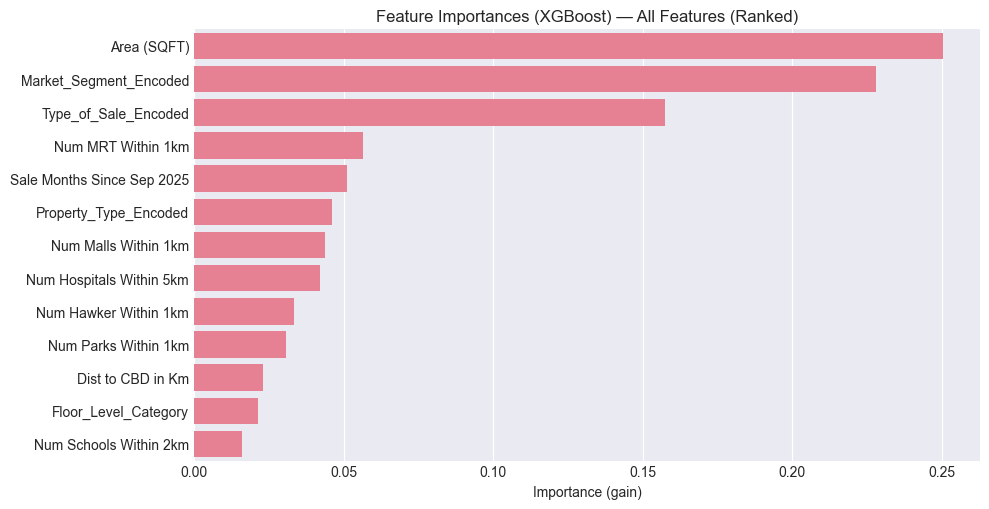

<Figure size 640x480 with 0 Axes>

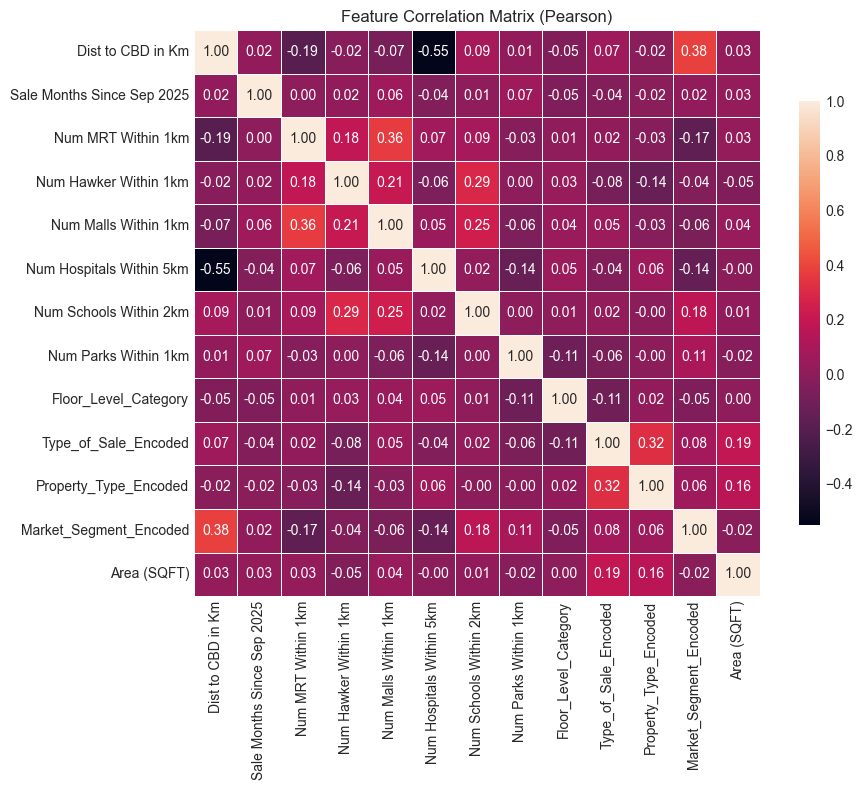

<Figure size 640x480 with 0 Axes>

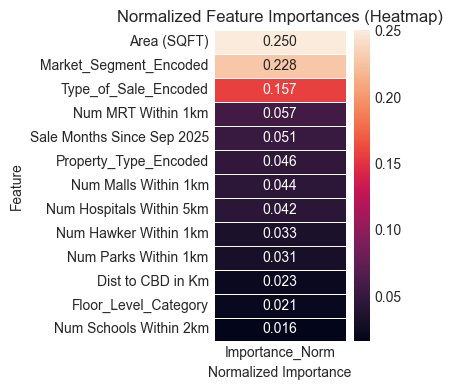


===== XGBoost Model Summary =====
R2: 0.9821
RMSE: 0.1346
MAE: 0.0866
MAPE: 319636.2269
CV_R2_mean: 0.8273
CV_R2_std: 0.1167
CV_RMSE_mean: 0.4052
CV_MAE_mean: 0.1021
CV_MAPE_mean: 319466.5436


In [11]:
print("="*80)
print("XGBOOST ANALYSIS")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'Area (SQFT)'
]

feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# Prepare Data
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# XGBoost Configuration 
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Full-Sample Fit 
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# Cross-Validation Metrics 
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for fold_id, (train_idx, val_idx) in enumerate(kf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

    print(f"Fold {fold_id} metrics: R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, MAPE={m['MAPE']:.4f}")

# Aggregate CV Results 
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# Feature Importance (full ranking) 
importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
})

# Sort descending
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Add normalized and cumulative importance columns
total_imp = feat_imp_df['Importance'].sum() if feat_imp_df['Importance'].sum() > 0 else 1.0
feat_imp_df['Importance_Norm'] = feat_imp_df['Importance'] / total_imp
feat_imp_df['Importance_Cum'] = feat_imp_df['Importance_Norm'].cumsum()

print("\n===== Full Feature Importance Ranking =====")
print(feat_imp_df.to_string(index=False, float_format="{:.6f}".format))

# Bar plot of all features (ranked) 
plt.figure(figsize=(10, max(4, 0.4 * len(feature_cols)))) 
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', order=feat_imp_df['Feature'])
plt.title('Feature Importances (XGBoost) — All Features (Ranked)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()
# Optionally save:
plt.savefig("feature_importances_all_ranked.png", dpi=150, bbox_inches='tight')

# Correlation heatmap of features
corr_mat = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title('Feature Correlation Matrix (Pearson)')
plt.tight_layout()
plt.show()
# Optionally save:
plt.savefig("feature_correlation_heatmap.png", dpi=150, bbox_inches='tight')

# Feature importance heatmap (single-column normalized) 
imp_heat = feat_imp_df[['Feature', 'Importance_Norm']].set_index('Feature')

plt.figure(figsize=(4, max(4, 0.25 * len(feature_cols))))
sns.heatmap(imp_heat, annot=True, fmt=".3f", cbar=True, linewidths=0.5)
plt.title('Normalized Feature Importances (Heatmap)')
plt.xlabel('Normalized Importance')
plt.tight_layout()
plt.show()

# Summary Output 
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")


## XGBoost Excluding Area

XGBOOST ANALYSIS - EXCLUDING AREA

===== Full Sample Metrics =====
R2: 0.7674
RMSE: 0.4849
MAE: 0.2818
MAPE: 276425.2663

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.1997
CV_R2_std: 0.0811
CV_RMSE_mean: 0.8974
CV_MAE_mean: 0.5147
CV_MAPE_mean: 287376.4168

===== Top Features by Importance =====
                 Feature  Importance
   Num Hawker Within 1km      0.1970
Num Hospitals Within 5km      0.1666
    Num Malls Within 1km      0.1242
       Dist to CBD in Km      0.1185
    Type_of_Sale_Encoded      0.0603
    Floor_Level_Category      0.0585
      Num MRT Within 1km      0.0571
   Property_Type_Encoded      0.0506
    Num Parks Within 1km      0.0484
  Market_Segment_Encoded      0.0442


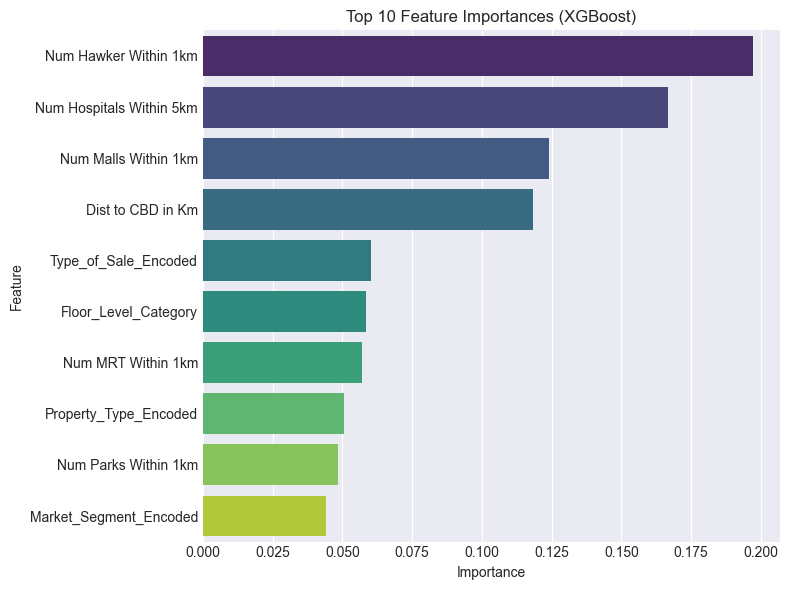


===== XGBoost Model Summary =====
R2: 0.7674
RMSE: 0.4849
MAE: 0.2818
MAPE: 276425.2663
CV_R2_mean: 0.1997
CV_R2_std: 0.0811
CV_RMSE_mean: 0.8974
CV_MAE_mean: 0.5147
CV_MAPE_mean: 287376.4168


In [13]:
print("="*80)
print("XGBOOST ANALYSIS - EXCLUDING AREA")
print("="*80)

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# Prepare Data 
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# XGBoost Configuration
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=10000,
    learning_rate=0.2,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=3,
    reg_alpha=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Full-Sample Fit
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# Cross-Validation Metrics
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

# Aggregate CV Results 
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# --- Feature Importance ---
import matplotlib.pyplot as plt
import seaborn as sns

importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\n===== Top Features by Importance =====")
print(feat_imp_df.head(10).to_string(index=False))

# Plot Feature Importances 
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# Summary Output 
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")


## XGBoost Per District

XGBOOST ANALYSIS PER DISTRICT
Running XGBoost model for 27 districts...


District 1 (n=1638) — training model...
  → R² = 0.747, CV R² = 0.104
  Top 3 features: ['Property_Type_Encoded', 'Num Hawker Within 1km', 'Dist to CBD in Km']

District 2 (n=1207) — training model...
  → R² = 0.970, CV R² = 0.412
  Top 3 features: ['Num MRT Within 1km', 'Floor_Level_Category', 'Sale Months Since Sep 2025']

District 3 (n=4625) — training model...
  → R² = 0.658, CV R² = 0.447
  Top 3 features: ['Num Hawker Within 1km', 'Num Hospitals Within 5km', 'Dist to CBD in Km']

District 4 (n=2112) — training model...
  → R² = 0.797, CV R² = 0.434
  Top 3 features: ['Num Hawker Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km']

District 5 (n=7943) — training model...
  → R² = 0.600, CV R² = 0.449
  Top 3 features: ['Num MRT Within 1km', 'Type_of_Sale_Encoded', 'Property_Type_Encoded']

District 6 (n=705) — training model...
  → R² = 0.506, CV R² = 0.069
  Top 3 features: ['Num MRT Within 1km

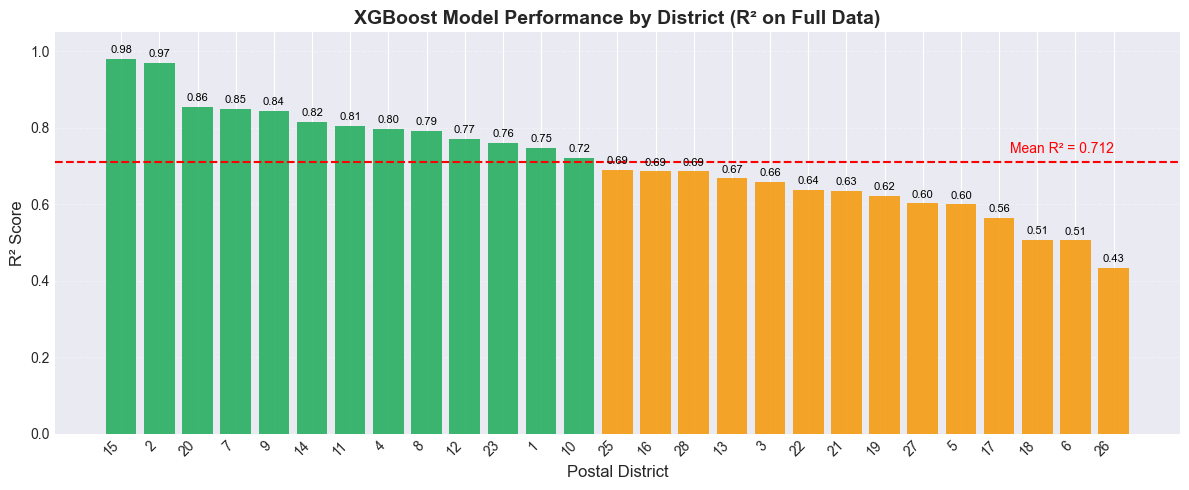

In [14]:
print("="*80)
print("XGBOOST ANALYSIS PER DISTRICT")
print("="*80)

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

target_col = 'Transacted Price ($)'
district_col = 'District'

feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
feature_cols = [f for f in feature_cols if f in df.columns]

MIN_ROWS_PER_DISTRICT = 100
CV_FOLDS = 5
RANDOM_STATE = 42
EPS = 1e-6

# XGBoost Parameters 
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }


district_metrics = []  # for RMSE, R2, etc.
district_importances = []  # for feature importance

districts = sorted(df[district_col].dropna().unique())

print(f"Running XGBoost model for {len(districts)} districts...\n")

# Loop over districts
for dist in districts:
    df_dist = df[df[district_col] == dist].dropna(subset=[target_col] + feature_cols).copy()
    n = len(df_dist)
    if n < MIN_ROWS_PER_DISTRICT:
        print(f"Skipping District {dist} — only {n} samples (< {MIN_ROWS_PER_DISTRICT})")
        continue

    print(f"\nDistrict {dist} (n={n}) — training model...")

    X = df_dist[feature_cols].astype(float)
    y = df_dist[target_col].astype(float)

    # Full Sample Fit
    model_full = XGBRegressor(**xgb_params)
    model_full.fit(X, y)
    y_pred_full = model_full.predict(X)
    full_metrics = compute_metrics(y, y_pred_full)

    # Cross-Validation
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

    for tr_idx, val_idx in kf.split(X, y):
        X_train, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model_cv = XGBRegressor(**xgb_params)
        model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        y_val_pred = model_cv.predict(X_val)
        m = compute_metrics(y_val, y_val_pred)

        cv_r2s.append(m['R2'])
        cv_rmses.append(m['RMSE'])
        cv_maes.append(m['MAE'])
        cv_mapes.append(m['MAPE'])

    cv_results = {
        'District': dist,
        'n': n,
        'R2_full': full_metrics['R2'],
        'RMSE_full': full_metrics['RMSE'],
        'MAE_full': full_metrics['MAE'],
        'MAPE_full': full_metrics['MAPE'],
        'CV_R2_mean': np.mean(cv_r2s),
        'CV_R2_std': np.std(cv_r2s),
        'CV_RMSE_mean': np.mean(cv_rmses),
        'CV_MAE_mean': np.mean(cv_maes),
        'CV_MAPE_mean': np.mean(cv_mapes)
    }
    district_metrics.append(cv_results)

    # Feature Importance 
    imp = model_full.feature_importances_
    imp_df = pd.DataFrame({
        'District': dist,
        'Feature': feature_cols,
        'Importance': imp
    }).sort_values('Importance', ascending=False)
    district_importances.append(imp_df)

    print(f"  → R² = {full_metrics['R2']:.3f}, CV R² = {cv_results['CV_R2_mean']:.3f}")
    print(f"  Top 3 features: {imp_df.head(3)['Feature'].tolist()}")

# Combine all results
metrics_df = pd.DataFrame(district_metrics)
importances_df = pd.concat(district_importances, ignore_index=True)

# Summary of Top Features per District 
top_features = (
    importances_df.sort_values(['District','Importance'], ascending=[True, False])
    .groupby('District')
    .first()
    .reset_index()[['District','Feature','Importance']]
)
top_features = top_features.merge(
    metrics_df[['District','CV_R2_mean','CV_RMSE_mean','n']],
    on='District', how='left'
).sort_values('CV_R2_mean', ascending=False)

print("\n===== Top Feature per District (Ranked by CV R²) =====")
print(top_features.head(10).to_string(index=False))

# Sort districts by R² descending
metrics_sorted = metrics_df.sort_values("R2_full", ascending=False).reset_index(drop=True)

# Calculate mean R²
mean_r2 = metrics_sorted["R2_full"].mean()

# Define colors: green if above mean, orange if below
colors = [
    "#27ae60" if r2 >= mean_r2 else "#f39c12"
    for r2 in metrics_sorted["R2_full"
]]

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(
    metrics_sorted["District"].astype(str),
    metrics_sorted["R2_full"],
    color=colors,
    alpha=0.9
)

# Add mean R² reference line
plt.axhline(mean_r2, color="red", linestyle="--", linewidth=1.5)
plt.text(
    len(metrics_sorted) - 1, mean_r2 + 0.015,
    f"Mean R² = {mean_r2:.3f}",
    color="red", fontsize=10, ha="right", va="bottom"
)

# Add text labels on top of bars (optional)
for i, (dist, r2) in enumerate(zip(metrics_sorted["District"], metrics_sorted["R2_full"])):
    plt.text(i, r2 + 0.01, f"{r2:.2f}", ha="center", va="bottom", fontsize=8, color="black")

# Customize chart
plt.title("XGBoost Model Performance by District (R² on Full Data)", fontsize=14, fontweight="bold")
plt.xlabel("Postal District", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


## Finalized XGBoost - Hyperparameter Tuned


===== Full Sample Metrics =====
R2: 0.9519
RMSE: 0.2206
MAE: 0.1347
MAPE: 314538.3442
Fold 1 metrics: R2=0.9094, RMSE=0.2751, MAE=0.1405, MAPE=313167.9597
Fold 2 metrics: R2=0.8339, RMSE=0.4001, MAE=0.1457, MAPE=311681.5879
Fold 3 metrics: R2=0.8963, RMSE=0.3083, MAE=0.1419, MAPE=312416.5861
Fold 4 metrics: R2=0.7914, RMSE=0.4584, MAE=0.1417, MAPE=317122.0447
Fold 5 metrics: R2=0.6084, RMSE=0.7223, MAE=0.1480, MAPE=317299.0945

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.8079
CV_R2_std: 0.1085
CV_RMSE_mean: 0.4328
CV_MAE_mean: 0.1435
CV_MAPE_mean: 314337.4546

===== Full Feature Importance Ranking =====
                   Feature  Importance  Importance_Norm  Importance_Cum
               Area (SQFT)    0.278421         0.278421        0.278421
    Market_Segment_Encoded    0.165758         0.165758        0.444179
      Type_of_Sale_Encoded    0.137994         0.137994        0.582173
Sale Months Since Sep 2025    0.075967         0.075967        0.658140
      Num Ma

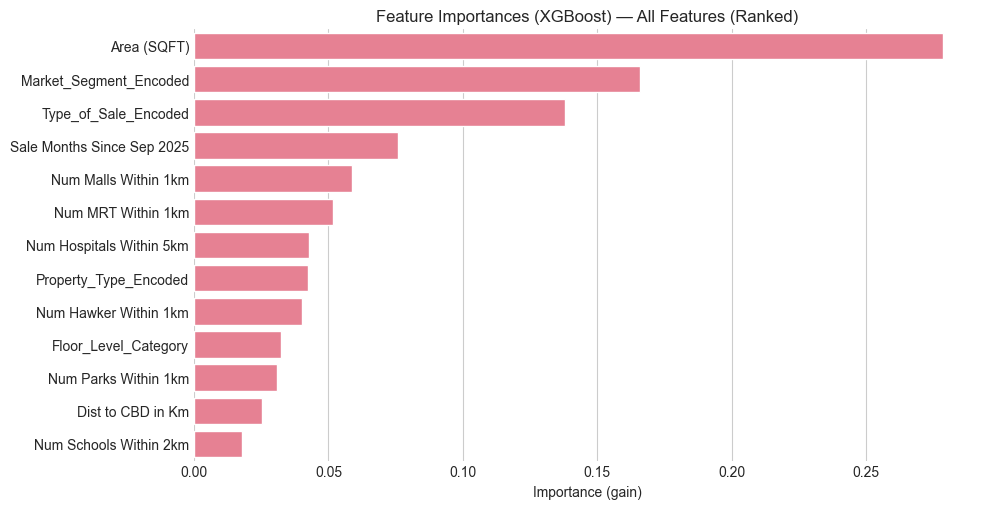

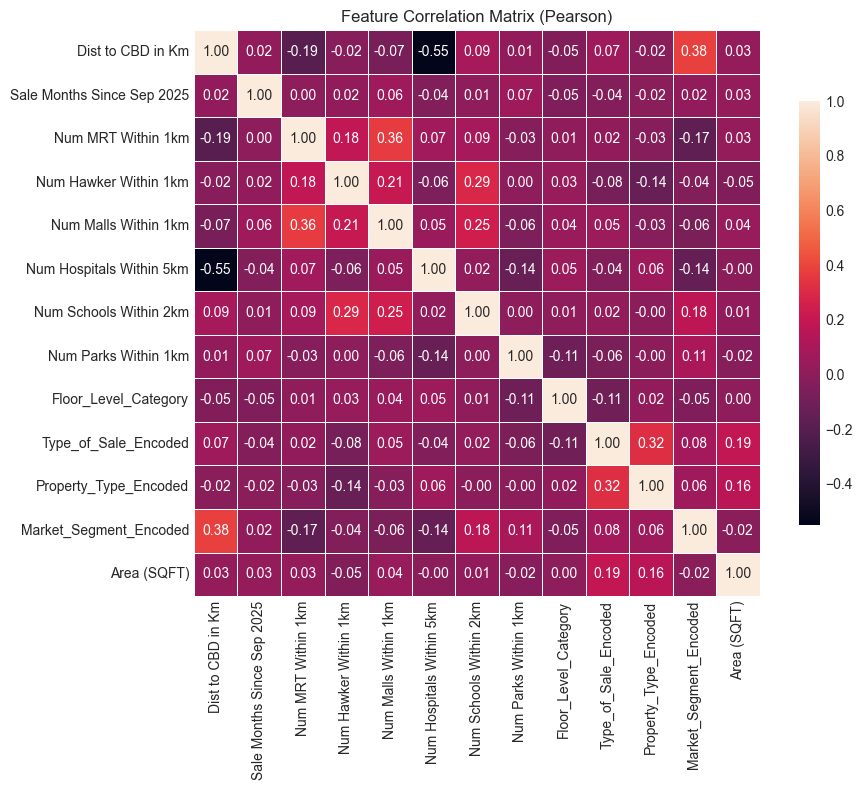

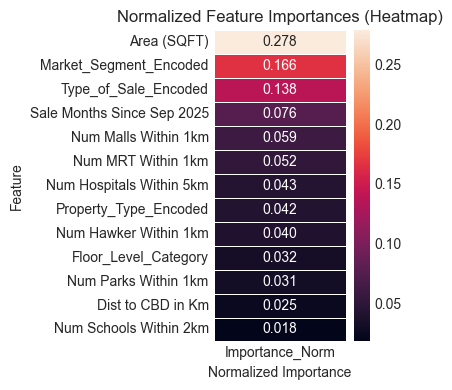

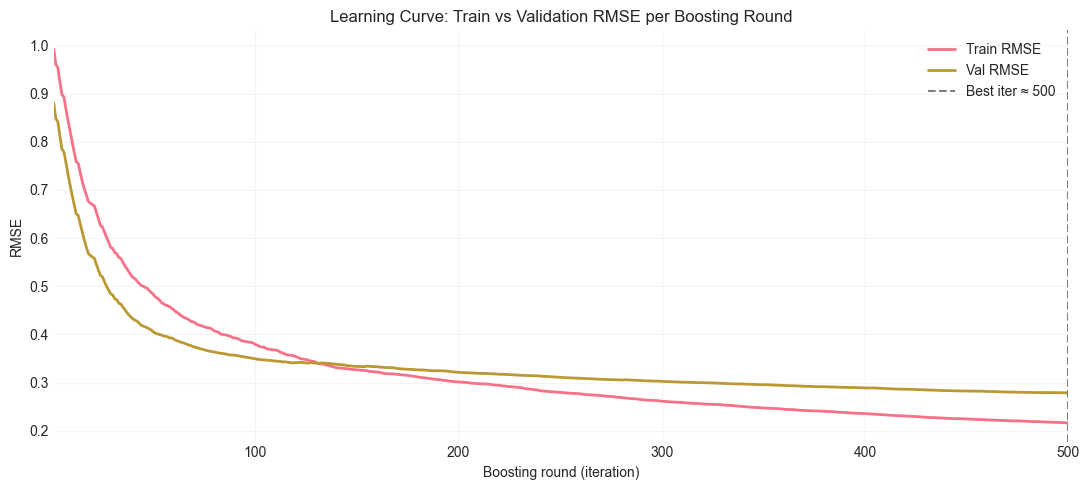


===== Learning Curve Stats =====
Recorded iterations: 500
Best iteration (0-based): 499
Best iteration (1-based): 500
Train RMSE final: 0.2161
Val RMSE final:   0.2783
Min Val RMSE:     0.2783 (at iter 500)

===== XGBoost Model Summary =====
R2: 0.9519
RMSE: 0.2206
MAE: 0.1347
MAPE: 314538.3442
CV_R2_mean: 0.8079
CV_R2_std: 0.1085
CV_RMSE_mean: 0.4328
CV_MAE_mean: 0.1435
CV_MAPE_mean: 314337.4546


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'Area (SQFT)'
]

# Keep only features present in df
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# Safe metrics
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# Prepare Data
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# XGBoost Configuration (sklearn wrapper params)
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

# Full-Sample Fit
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# Cross-Validation Metrics (sklearn wrapper)
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for fold_id, (train_idx, val_idx) in enumerate(kf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

    print(f"Fold {fold_id} metrics: R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, MAPE={m['MAPE']:.4f}")

# Aggregate CV Results
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# Feature Importance (full ranking)
importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
})

# Sort descending
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Add normalized and cumulative importance columns
total_imp = feat_imp_df['Importance'].sum() if feat_imp_df['Importance'].sum() > 0 else 1.0
feat_imp_df['Importance_Norm'] = feat_imp_df['Importance'] / total_imp
feat_imp_df['Importance_Cum'] = feat_imp_df['Importance_Norm'].cumsum()

print("\n===== Full Feature Importance Ranking =====")
print(feat_imp_df.to_string(index=False, float_format="{:.6f}".format))

sns.set_style("whitegrid")

# Bar plot of all features (ranked) 
plt.figure(figsize=(10, max(4, 0.4 * len(feature_cols))))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', order=feat_imp_df['Feature'])
plt.title('Feature Importances (XGBoost) — All Features (Ranked)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Correlation heatmap of features
corr_mat = X.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title('Feature Correlation Matrix (Pearson)')
plt.tight_layout()
plt.show()

# Feature importance heatmap (single-column normalized)
imp_heat = feat_imp_df[['Feature', 'Importance_Norm']].set_index('Feature')
plt.figure(figsize=(4, max(4, 0.25 * len(feature_cols))))
sns.heatmap(imp_heat, annot=True, fmt=".3f", cbar=True, linewidths=0.5)
plt.title('Normalized Feature Importances (Heatmap)')
plt.xlabel('Normalized Importance')
plt.tight_layout()
plt.show()

# 1. Create train/validation split for learning curve
X_lc, X_val_lc, y_lc, y_val_lc = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# 2. Convert to DMatrix (XGBoost's native format)
dtrain = xgb.DMatrix(X_lc, label=y_lc)
dval = xgb.DMatrix(X_val_lc, label=y_val_lc)
watchlist = [(dtrain, 'train'), (dval, 'validation')]

# 3. Prepare params for xgb.train 
train_params = xgb_params.copy()
for k in ['n_estimators', 'random_state', 'n_jobs', 'verbosity']:
    train_params.pop(k, None)

# Ensure eval_metric and tree method are set
train_params['eval_metric'] = train_params.get('eval_metric', 'rmse')
train_params['tree_method'] = train_params.get('tree_method', 'hist')  # change to 'gpu_hist' if using GPU

# 4. Set number of boosting rounds and early stopping rounds
num_boost_round = xgb_params.get('n_estimators', 1000)
early_stopping_rounds = 50

# 5. container for eval results
evals_result = {}

# 6. Call xgboost.train (this supports early_stopping_rounds and returns history)
bst = xgb.train(
    params=train_params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    early_stopping_rounds=early_stopping_rounds,
    evals_result=evals_result,
    verbose_eval=False
)

# 7. Extract RMSE history
train_rmse = np.array(evals_result.get('train', {}).get('rmse', []), dtype=float)
val_rmse   = np.array(evals_result.get('validation', {}).get('rmse', []), dtype=float)
n_iters = len(train_rmse)
iters = np.arange(1, n_iters + 1)

# 8. Best iteration from booster
best_iter = getattr(bst, "best_iteration", None)
if best_iter is None:
    # fallback: minimal val rmse index
    if n_iters > 0:
        best_iter = int(np.argmin(val_rmse))
    else:
        best_iter = 0
# convert to 1-based index for plotting clarity
best_iter_plot = best_iter + 1

# 9. Plot learning curve
plt.figure(figsize=(11,5))
plt.plot(iters, train_rmse, label='Train RMSE', linewidth=2)
plt.plot(iters, val_rmse, label='Val RMSE', linewidth=2)
plt.axvline(x=best_iter_plot, color='gray', linestyle='--', label=f'Best iter ≈ {best_iter_plot}')
plt.xlim(1, max(50, n_iters))
plt.xlabel('Boosting round (iteration)')
plt.ylabel('RMSE')
plt.title('Learning Curve: Train vs Validation RMSE per Boosting Round')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 10. Print concise stats
print("\n===== Learning Curve Stats =====")
print(f"Recorded iterations: {n_iters}")
print(f"Best iteration (0-based): {best_iter}")
print(f"Best iteration (1-based): {best_iter_plot}")
if n_iters > 0:
    print(f"Train RMSE final: {train_rmse[-1]:.4f}")
    print(f"Val RMSE final:   {val_rmse[-1]:.4f}")
    print(f"Min Val RMSE:     {val_rmse.min():.4f} (at iter {int(np.argmin(val_rmse))+1})")

# Summary Output
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")
